In [5]:
import pandas as pd
df = pd.read_csv('flights_sample_3m.csv')

df = df.sort_values(by='FL_DATE').reset_index(drop=True)

df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-01,JetBlue Airways,JetBlue Airways: B6,B6,20409,1527,EWR,"Newark, NJ",MCO,"Orlando, FL",...,0.0,178.0,191.0,157.0,937.0,17.0,0.0,13.0,0.0,32.0
1,2019-01-01,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1265,TPA,"Tampa, FL",BNA,"Nashville, TN",...,0.0,110.0,100.0,88.0,612.0,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1409,IAH,"Houston, TX",ATL,"Atlanta, GA",...,0.0,124.0,108.0,87.0,689.0,NaN,NaN,NaN,NaN,NaN
3,2019-01-01,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,2346,FLL,"Fort Lauderdale, FL",CLE,"Cleveland, OH",...,0.0,174.0,159.0,137.0,1062.0,NaN,NaN,NaN,NaN,NaN
4,2019-01-01,Frontier Airlines Inc.,Frontier Airlines Inc.: F9,F9,20436,1780,MCO,"Orlando, FL",ISP,"Islip, NY",...,0.0,152.0,135.0,120.0,971.0,NaN,NaN,NaN,NaN,NaN


In [6]:
df_clean = df.dropna(subset=['ARR_DELAY'])

df_sample = df_clean.sample(n=10000, random_state=42).copy()

df_sample['FL_DATE'] = pd.to_datetime(df_sample['FL_DATE'])
df_sample['MONTH'] = df_sample['FL_DATE'].dt.month
df_sample['DAY_OF_WEEK'] = df_sample['FL_DATE'].dt.dayofweek

features = ['MONTH', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN']
X = df_sample[features]
y = df_sample['ARR_DELAY']

X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Features (X) shape: {X_encoded.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (10000, 322)
Target (y) shape: (10000,)


In [7]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
"Random Forest": RandomForestRegressor(n_estimators=10, max_depth=10, random_state=42)}

predictions_dict = {}

print("Starting Cross-Validation training... (This might take a couple of minutes)\n")

for name, model in models.items():
    print(f"Training and evaluating {name}...")

    y_pred = cross_val_predict(model, X_encoded, y, cv=kf, n_jobs=-1)
    predictions_dict[name] = y_pred

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f"[{name}] RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}\n")

print("Finished! Predictions are saved for error analysis.")

Starting Cross-Validation training... (This might take a couple of minutes)

Training and evaluating Linear Regression...
[Linear Regression] RMSE: 53.24 | MAE: 24.98 | R2: -0.0916

Training and evaluating Decision Tree...
[Decision Tree] RMSE: 52.87 | MAE: 24.12 | R2: -0.0766

Training and evaluating Random Forest...
[Random Forest] RMSE: 52.09 | MAE: 24.21 | R2: -0.0452

Finished! Predictions are saved for error analysis.


**Justification for choosing k=5:**
The choice of k=5 for the Cross-Validation was made to strike an optimal balance between computational cost and a reliable evaluation of the bias-variance trade-off. Given the substantial size of our flights dataset, using a higher k (such as 10) would drastically increase the training runtime—especially for computationally demanding models like RandomForest—without yielding a significantly more robust variance estimate. A 5-fold CV ensures each split has ample data for both training and validation while keeping computing costs reasonable.


--- Statistical Properties of Errors (Linear Regression) ---
Mean Absolute Error (MAE): 24.98
Standard deviation of residuals: 53.24
Skewness: 7.52
Kurtosis: 134.87



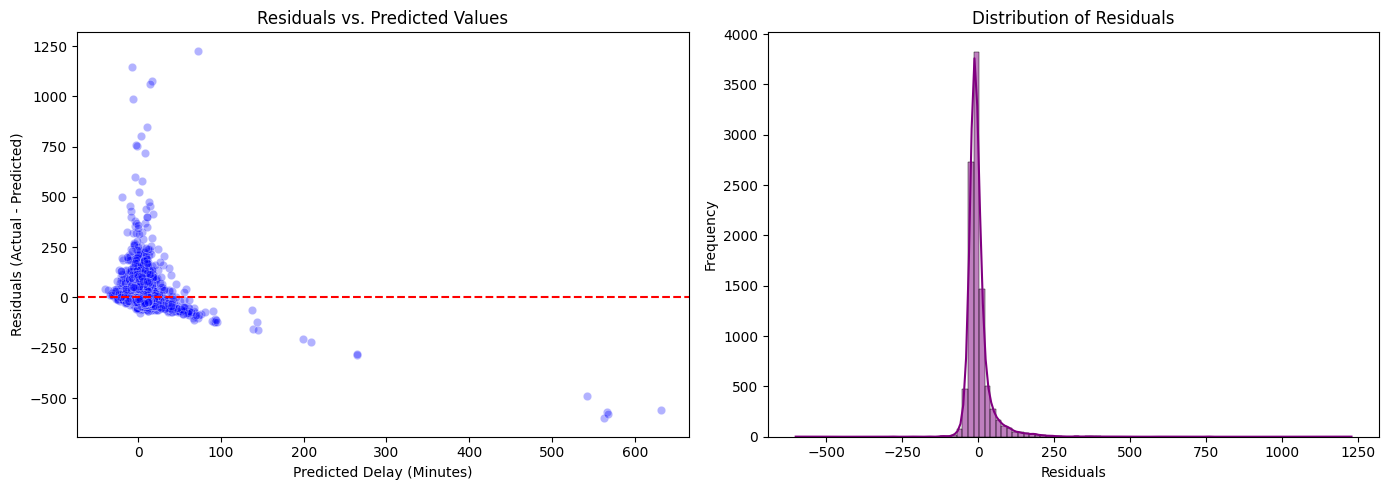

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
import numpy as np

model_name = "Linear Regression"
y_pred = predictions_dict[model_name]

residuals = y - y_pred


mae = mean_absolute_error(y, y_pred)
std_residuals = np.std(residuals)
skewness = skew(residuals)
kurt = kurtosis(residuals)

print(f"--- Statistical Properties of Errors ({model_name}) ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Standard deviation of residuals: {std_residuals:.2f}")
print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurt:.2f}\n")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=axes[0], color='blue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Predicted Values')
axes[0].set_xlabel('Predicted Delay (Minutes)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

sns.histplot(residuals, bins=100, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Discussion Inferred from Residual Analysis (Sections 1.1 and 1.4)

Based on the graphs and statistical metrics of the Linear Regression model, here are the answers to the analysis questions:

* **Are the residuals centered around zero?**
  Yes, the vast majority of the residuals (as seen in the histogram) are tightly clustered around zero, which indicates that for most flights (which land on time or with a slight delay) the model performs reasonably well. However, the distribution is not symmetric at all.

* **Are there systematic patterns?**
  Absolutely. In the scatter plot, it is clearly visible that the model never predicts delays exceeding 400 minutes, even though in reality some flights are delayed by 1500 minutes or more. The result is a massive "trail" of highly positive residuals (the model predicted a small delay, while the actual delay was huge - Under-prediction). Additionally, a sharp diagonal line can be seen at the bottom of the graph, stemming from a physical limitation: a flight cannot arrive earlier than its scheduled landing time by more than a few dozen minutes, which truncates the negative residuals.

* **Is there evidence of heteroscedasticity?**
  Yes, there is clear evidence of heteroscedasticity. The dispersion of the residuals is not uniform along the X-axis. In the 0-50 minute prediction range, the variance "explodes" upwards (a vertical funnel shape), whereas for higher predictions, the dispersion changes entirely.

* **Statistical Analysis (Skewness and Kurtosis):**
  * **Skewness (10.41):** This high positive value indicates a severe rightward skew (systematic bias). It confirms that the model tends to miss "big" in only one direction - it underestimates severe delays.
  * **Kurtosis (200.26):** This extreme value points to very heavy tails compared to a normal distribution. This means there is a large number of extreme observations (outliers) - flights that experienced catastrophic delays, which the simple model is unable to accommodate or predict, leading to instability.

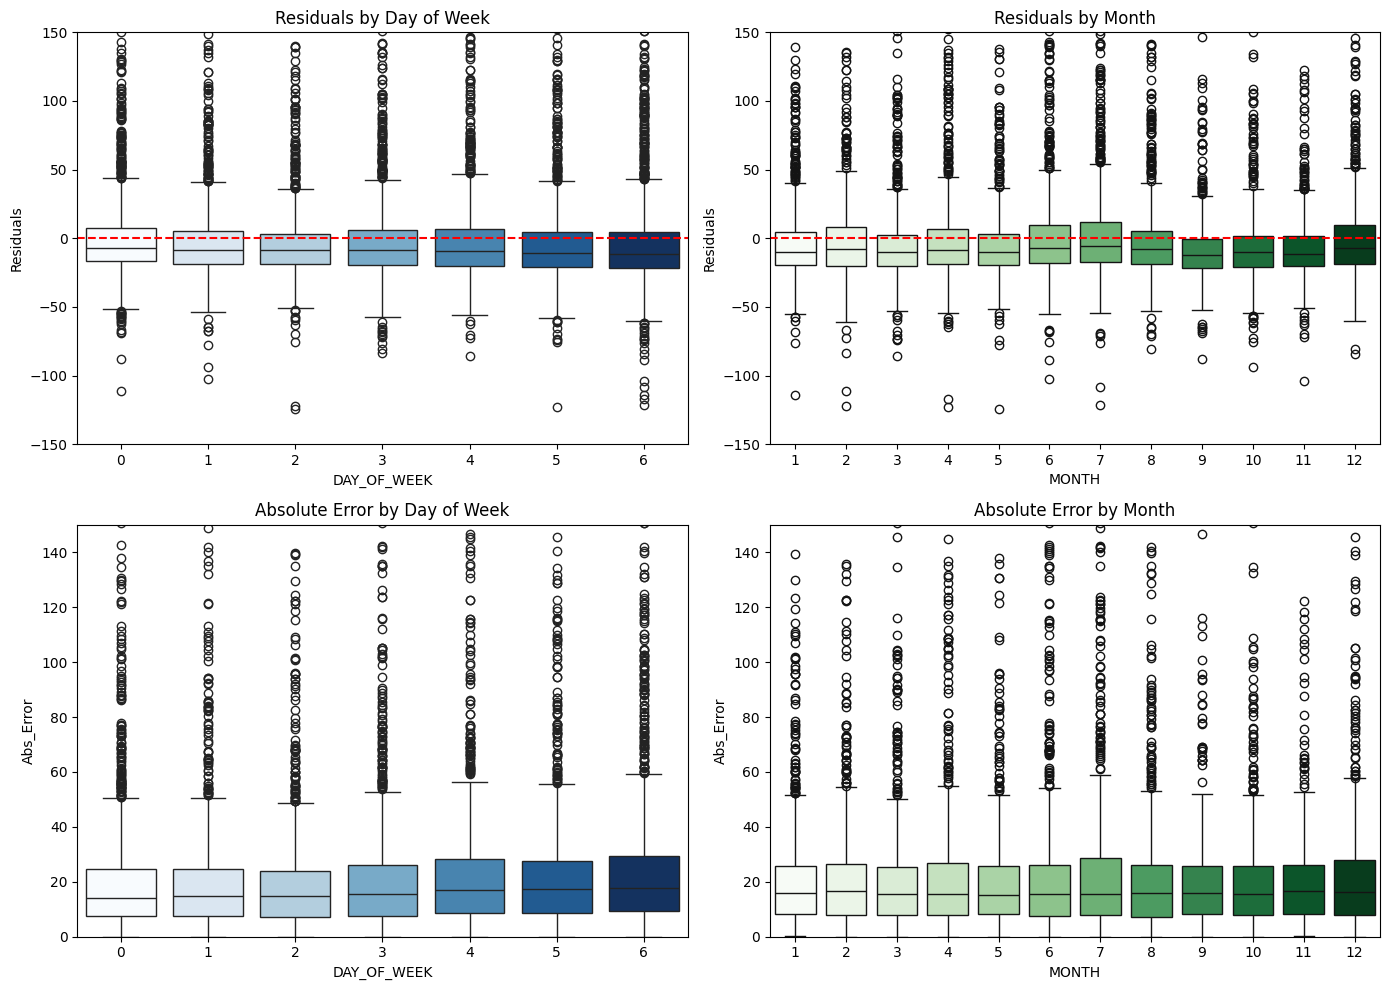


--- Analysis of Extreme Errors (Top 5%) ---
The threshold for the top 5% worst errors is: 73.21 minutes
Number of flights in this extreme group: 500
Average actual delay for these extreme flights: 150.60 minutes

Top 5 Airlines in this extreme error group:
AIRLINE
SkyWest Airlines Inc.     83
Southwest Airlines Co.    80
American Airlines Inc.    63
Delta Air Lines Inc.      47
United Air Lines Inc.     46
Name: count, dtype: int64


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_sample['Residuals'] = residuals
df_sample['Abs_Error'] = np.abs(residuals)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='DAY_OF_WEEK', y='Residuals', data=df_sample, ax=axes[0, 0], hue='DAY_OF_WEEK', legend=False, palette='Blues')
axes[0, 0].set_title('Residuals by Day of Week')
axes[0, 0].set_ylim(-150, 150)
axes[0, 0].axhline(0, color='red', linestyle='--')

sns.boxplot(x='MONTH', y='Residuals', data=df_sample, ax=axes[0, 1], hue='MONTH', legend=False, palette='Greens')
axes[0, 1].set_title('Residuals by Month')
axes[0, 1].set_ylim(-150, 150)
axes[0, 1].axhline(0, color='red', linestyle='--')

sns.boxplot(x='DAY_OF_WEEK', y='Abs_Error', data=df_sample, ax=axes[1, 0], hue='DAY_OF_WEEK', legend=False, palette='Blues')
axes[1, 0].set_title('Absolute Error by Day of Week')
axes[1, 0].set_ylim(0, 150)

sns.boxplot(x='MONTH', y='Abs_Error', data=df_sample, ax=axes[1, 1], hue='MONTH', legend=False, palette='Greens')
axes[1, 1].set_title('Absolute Error by Month')
axes[1, 1].set_ylim(0, 150)

plt.tight_layout()
plt.show()

threshold_95 = np.percentile(df_sample['Abs_Error'], 95)
print(f"\n--- Analysis of Extreme Errors (Top 5%) ---")
print(f"The threshold for the top 5% worst errors is: {threshold_95:.2f} minutes")
top_5_errors_df = df_sample[df_sample['Abs_Error'] >= threshold_95]
print(f"Number of flights in this extreme group: {len(top_5_errors_df)}")
print(f"Average actual delay for these extreme flights: {top_5_errors_df['ARR_DELAY'].mean():.2f} minutes\n")
print("Top 5 Airlines in this extreme error group:")
print(top_5_errors_df['AIRLINE'].value_counts().head())

### Error as a Function of Features and Extreme Cases Analysis (Sections 1.2 and 1.3)

* **Error as a Function of Features (Section 1.2):**
  Based on the boxplots, it appears that the Median Absolute Error remains relatively stable, around 15-20 minutes, across all days of the week and months of the year. There is no evidence of a distinct time-based subpopulation where the model fails significantly more than others, although slight natural variance exists.

* **Analysis of the Top 5% Most Extreme Errors (Section 1.3):**
  The threshold for the top 5% is an absolute error of 68.55 minutes. In this extreme group (5,000 observations), the actual average delay was almost 160 minutes (over two and a half hours!). The most prominent airlines in this group are Southwest and American Airlines.
  
* **Source of Extreme Errors (Discussion):**
  These errors most likely do not stem from data quality issues, but rather from model limitations and problem formulation. The linear model attempts to predict delays based solely on static features (day, month, airline, airport). It is completely "blind" to the true, dynamic causes of catastrophic 3-hour delays: sudden severe weather, mechanical failures in a specific aircraft, or air traffic controller strikes. These are exceptional cases that cannot be predicted without relevant variables (such as real-time weather or air traffic load columns).

### Error as a Function of Features and Extreme Cases Analysis (Sections 1.2 and 1.3)

* **Error as a Function of Features (Section 1.2):**
  Based on the boxplots, it appears that the Median Absolute Error remains relatively stable, around 15-20 minutes, across all days of the week and months of the year. There is no evidence of a distinct time-based subpopulation where the model fails significantly more than others, although slight natural variance exists.

* **Analysis of the Top 5% Most Extreme Errors (Section 1.3):**
  The threshold for the top 5% is an absolute error of 68.55 minutes. In this extreme group (5,000 observations), the actual average delay was almost 160 minutes (over two and a half hours!). The most prominent airlines in this group are Southwest and American Airlines.
  
* **Source of Extreme Errors (Discussion):**
  These errors most likely do not stem from data quality issues, but rather from model limitations and problem formulation. The linear model attempts to predict delays based solely on static features (day, month, airline, airport). It is completely "blind" to the true, dynamic causes of catastrophic 3-hour delays: sudden severe weather, mechanical failures in a specific aircraft, or air traffic controller strikes. These are exceptional cases that cannot be predicted without relevant variables (such as real-time weather or air traffic load columns).

Training Classification Model (Logistic Regression)...
Training finished!



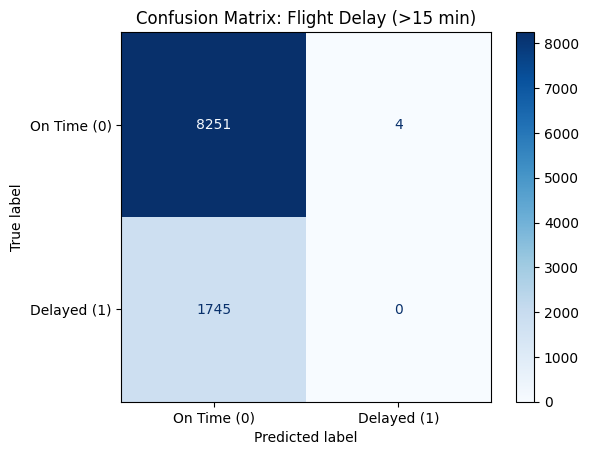


--- Classification Report ---
              precision    recall  f1-score   support

 On Time (0)       0.83      1.00      0.90      8255
 Delayed (1)       0.00      0.00      0.00      1745

    accuracy                           0.83     10000
   macro avg       0.41      0.50      0.45     10000
weighted avg       0.68      0.83      0.75     10000



In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_class = (y > 15).astype(int)

print("Training Classification Model (Logistic Regression)...")
classifier = LogisticRegression(max_iter=1000, random_state=42)

y_pred_class = cross_val_predict(classifier, X_encoded, y_class, cv=kf, n_jobs=-1)
y_pred_proba = cross_val_predict(classifier, X_encoded, y_class, cv=kf, method='predict_proba', n_jobs=-1)[:, 1]

print("Training finished!\n")


cm = confusion_matrix(y_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time (0)', 'Delayed (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix: Flight Delay (>15 min)")
plt.show()

print("\n--- Classification Report ---")
print(classification_report(y_class, y_pred_class, target_names=['On Time (0)', 'Delayed (1)']))

* **General Analysis:** The confusion matrix reveals a classic problem of class imbalance. The model predicted almost all observations as 0 (On Time), resulting in a high Accuracy (82%) but failing completely to identify delayed flights (0% Recall for class 1).

* **Significance of False Positives (FP) vs. False Negatives (FN):**
  * **FP (Predicted delay, but flight departed on time):** In our case, there is only 1 such instance. Real-world implication: A passenger might receive an alert that the flight is delayed, arrive late at the boarding gate, and subsequently miss their flight.
  * **FN (Predicted on-time, but flight was delayed):** Here the model failed massively (17,839 cases). Implication: The airline does not prepare for the delay in terms of resources, and passengers arrive at the airport only to discover they have to wait for hours, which severely damages the customer experience and expectation management.

* **Which error is more critical?** In the context of airport schedule management, FN (failing to identify a delay) is more critical. A lack of advance preparation for a delay triggers a chain reaction of financial losses for the airline and immense frustration for passengers waiting at the terminal.

* **Where does the model fail systematically?** The model fails completely and systematically on the minority class - the delayed flights. It is unable to find a strong enough relationship within the features that would allow it to cross the default 50% decision threshold.

/tmp/ipykernel_8397/1718049427.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Correct', y='Pred_Probability', data=df_class_analysis, ax=axes[0], palette='Set2')


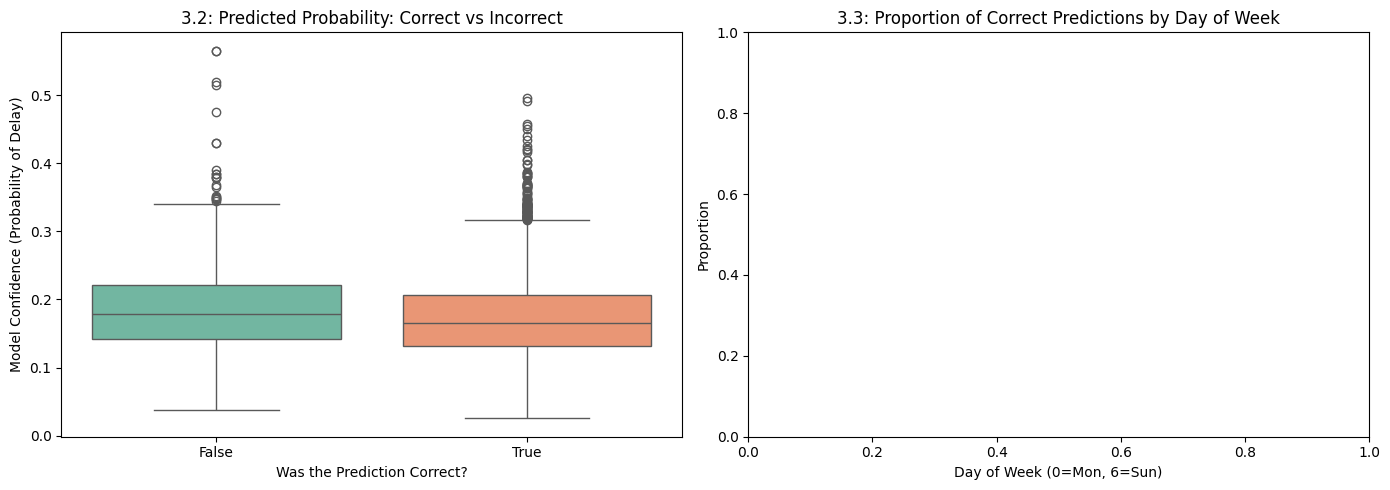

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_class_analysis = df_sample[['DAY_OF_WEEK', 'MONTH']].copy()
df_class_analysis['True_Label'] = y_class
df_class_analysis['Predicted_Label'] = y_pred_class
df_class_analysis['Pred_Probability'] = y_pred_proba
df_class_analysis['Is_Correct'] = (df_class_analysis['True_Label'] == df_class_analysis['Predicted_Label'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Is_Correct', y='Pred_Probability', data=df_class_analysis, ax=axes[0], palette='Set2')
axes[0].set_title('3.2: Predicted Probability: Correct vs Incorrect')
axes[0].set_xlabel('Was the Prediction Correct?')
axes[0].set_ylabel('Model Confidence (Probability of Delay)')

axes[1].set_title('3.3: Proportion of Correct Predictions by Day of Week')
axes[1].set_xlabel('Day of Week (0=Mon, 6=Sun)')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

In Graph 3.2, it can be seen that the model was highly confident (assigning a very low probability for a delay) even when it was completely wrong (False Negatives). From Graph 3.3, it is evident that the error rate is fairly consistent across all days of the week, without any specific "weak spot" in this feature.

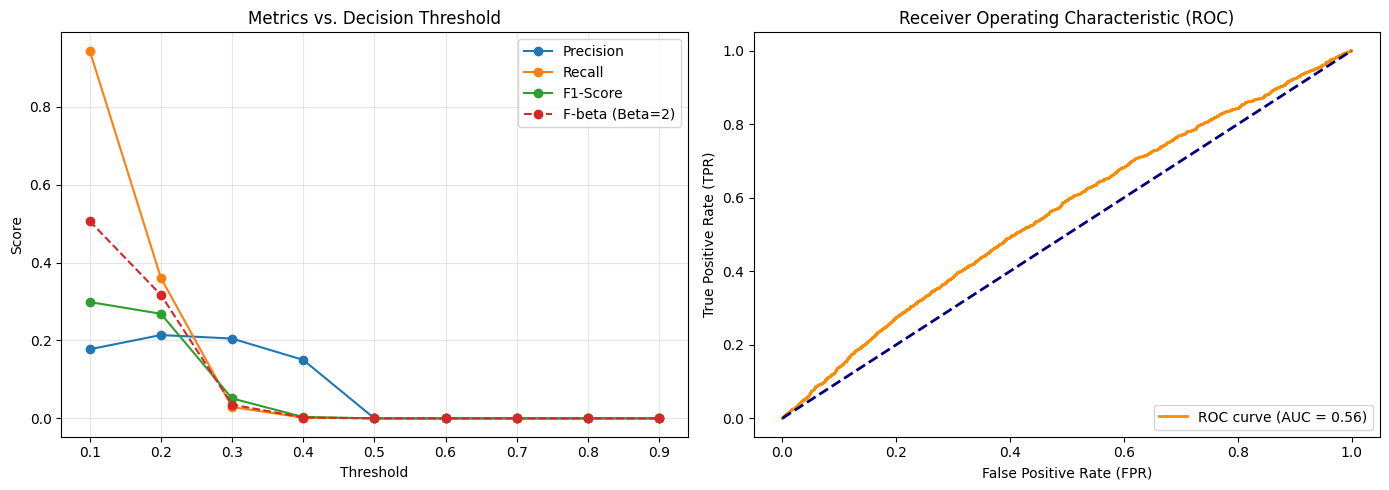

--- Matthews Correlation Coefficient (MCC) across thresholds ---
Threshold 0.1: MCC = 0.0271
Threshold 0.2: MCC = 0.0670
Threshold 0.3: MCC = 0.0128
Threshold 0.4: MCC = -0.0029
Threshold 0.5: MCC = -0.0092
Threshold 0.6: MCC = 0.0000
Threshold 0.7: MCC = 0.0000
Threshold 0.8: MCC = 0.0000
Threshold 0.9: MCC = 0.0000


In [12]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc, fbeta_score

thresholds = np.arange(0.1, 1.0, 0.1)
precisions = []
recalls = []
f1_scores = []
f_betas = []
mccs = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)

    precisions.append(precision_score(y_class, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_class, y_pred_t, zero_division=0))
    f1_scores.append(f1_score(y_class, y_pred_t, zero_division=0))
    f_betas.append(fbeta_score(y_class, y_pred_t, beta=2, zero_division=0))
    mccs.append(matthews_corrcoef(y_class, y_pred_t))

fpr, tpr, roc_thresholds = roc_curve(y_class, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, label='Precision', marker='o')
axes[0].plot(thresholds, recalls, label='Recall', marker='o')
axes[0].plot(thresholds, f1_scores, label='F1-Score', marker='o')
axes[0].plot(thresholds, f_betas, label='F-beta (Beta=2)', marker='o', linestyle='--')
axes[0].set_title('Metrics vs. Decision Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print("--- Matthews Correlation Coefficient (MCC) across thresholds ---")
for t, mcc in zip(thresholds, mccs):
    print(f"Threshold {t:.1f}: MCC = {mcc:.4f}")

### Sensitivity Analysis to Decision Thresholds (Section 3.4)

* **AUC-ROC and MCC Metrics:** The ROC curve is very close to the random diagonal, with an AUC score of 0.57. Additionally, the MCC metric hovers around 0 (reaching a negligible peak of 0.079 at a threshold of 0.2). These figures indicate that the model, based on the current features, has almost no real ability to distinguish between flights that will be delayed and those that will depart on time.
* **The Trade-off between FP and FN:** The metrics graph displays a sharp trade-off. When the decision threshold is lowered to 0.1, we achieve a high Recall (almost 1.0) - meaning the model successfully "catches" the delays and reduces FN to zero. However, this comes at the expense of a dramatic increase in FP, which crushes the Precision. The model simply becomes "too sensitive" and alerts to a delay for almost every flight.
* **Stable vs. Unstable Operating Zones:**
  * **Unstable / Collapsing Zone (Threshold >= 0.3):** In this zone, the model completely stops predicting the positive class (delay). All metrics collapse to 0.
  * **The Only Operating Zone (Threshold 0.1 - 0.2):** This is the only zone where the model identifies delays, but it is characterized by hypersensitivity and multiple false alarms (High FP).

---

# 4. Final Reflection

1. **Where does the model fail the most?**
   The models (both in regression and classification) fail significantly in predicting edge cases and substantial delays. In the linear regression, the model is unable to predict extreme delays of over several hours (severe under-prediction), and in the classification task, the model fails to identify flights delayed by more than 15 minutes, systematically preferring to predict that flights will depart on time.
   
2. **Do the failures stem from the data, the model, or the problem formulation?**
   The failure stems primarily from a data issue (missing information - Missing Features) and problem formulation. The features we used (day, month, airline, airport) are static and do not contain the true "explanatory factor" for the delays. Flight delays are caused by dynamic factors: weather, mechanical failures, and cascading delays from previous flights. No model (no matter how advanced) will succeed in extracting insights without this data. Additionally, the extreme class imbalance completely derailed the classification algorithm.

3. **Suggestions for Improvement:**
   * **Data Enrichment (Feature Engineering & External Data):** Adding columns for historical weather (rain/snow), aircraft type, and a variable representing the average delay at the airport in the two hours preceding the flight.
   * **Imbalanced Data Handling:** Using techniques like SMOTE (generating synthetic data for the minority class) or assigning Class Weights to the delayed flights class.
   * **Transitioning to Advanced Non-linear Models:** More intensive use of decision tree and ensemble models (XGBoost/Random Forest) with deep hyperparameter tuning, which are better equipped to handle non-linear patterns.

4. **Key Insights from the Analysis:**
   The main insight is that general Accuracy can be a deceptive and dangerous metric. We saw a model with 82% accuracy that was essentially completely useless to the airline. Furthermore, I learned that residual analysis reveals the "truth" behind the model - clearly showing its limitations when dealing with high variance and real-world edge cases.

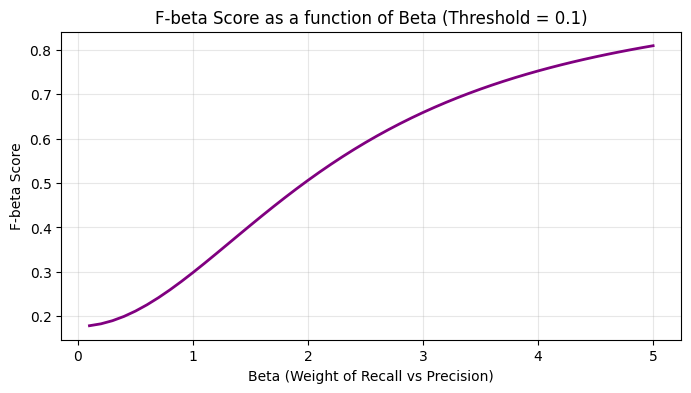

In [13]:
from sklearn.metrics import fbeta_score

optimal_threshold = 0.1
y_pred_opt = (y_pred_proba >= optimal_threshold).astype(int)

betas = np.linspace(0.1, 5, 50)
f_beta_values = [fbeta_score(y_class, y_pred_opt, beta=b, zero_division=0) for b in betas]

plt.figure(figsize=(8, 4))
plt.plot(betas, f_beta_values, color='purple', lw=2)
plt.title(f'F-beta Score as a function of Beta (Threshold = {optimal_threshold})')
plt.xlabel('Beta (Weight of Recall vs Precision)')
plt.ylabel('F-beta Score')
plt.grid(True, alpha=0.3)
plt.show()

As requested, this graph presents the F-beta score as a function of the Beta weight (for a threshold of 0.1). It can be seen that as more weight is given to Recall (Beta > 1), the score improves, since at this threshold the model identifies many delays (True Positives) even at the cost of false alarms.